Name - Harsh Kumar

PRN NO - 202301100054

BATCH - DL-4

In [19]:
# Install required libraries for the Mini-Former implementation
# tensorflow is pre-installed in Colab, we only need nltk and rouge for evaluation

!pip install nltk rouge-score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=c63310aebc8484275039dc6519bf903119ac2777a15c341a8072ffe988bc9026
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [1]:
# Import all required libraries

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random
import os
import time
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Download nltk punkt tokenizer data
nltk.download('punkt')

# Set random seeds for reproducibility This ensures the same results every time the notebook is run
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Check TensorFlow version and GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print("All libraries imported successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully


In [2]:
# Sample English-German sentence pairs for training
# This mimics the WMT14 dataset used in the original paper
# We use a small sample dataset to demonstrate the model on Colab
# In the original paper, the full WMT14 dataset with millions of pairs was used

english_sentences = [
    "i love you",
    "hello world",
    "how are you",
    "good morning",
    "thank you",
    "i am happy",
    "she is beautiful",
    "we are learning",
    "this is good",
    "i am fine",
    "the cat is here",
    "he goes to school",
    "i like music",
    "the weather is nice",
    "i want to eat",
    "she reads books",
    "we play football",
    "the dog is small",
    "i go to work",
    "you are my friend",
    "i love machine learning",
    "deep learning is powerful",
    "neural networks are amazing",
    "attention is all you need",
    "language models are useful",
    "i study every day",
    "the sun is bright",
    "birds fly in sky",
    "water is very cold",
    "the book is interesting",
]

german_sentences = [
    "ich liebe dich",
    "hallo welt",
    "wie geht es dir",
    "guten morgen",
    "danke schoen",
    "ich bin gluecklich",
    "sie ist schoen",
    "wir lernen gerade",
    "das ist gut",
    "ich bin gut",
    "die katze ist hier",
    "er geht zur schule",
    "ich mag musik",
    "das wetter ist schoen",
    "ich moechte essen",
    "sie liest buecher",
    "wir spielen fussball",
    "der hund ist klein",
    "ich gehe zur arbeit",
    "du bist mein freund",
    "ich liebe maschinelles lernen",
    "tiefes lernen ist maechtig",
    "neuronale netze sind erstaunlich",
    "aufmerksamkeit ist alles was du brauchst",
    "sprachmodelle sind nuetzlich",
    "ich lerne jeden tag",
    "die sonne ist hell",
    "voegel fliegen am himmel",
    "wasser ist sehr kalt",
    "das buch ist interessant",
]

print("Total sentence pairs:", len(english_sentences))
print("\nSample English sentence:", english_sentences[0])
print("Sample German sentence:", german_sentences[0])
print("\nDataset prepared successfully")

Total sentence pairs: 30

Sample English sentence: i love you
Sample German sentence: ich liebe dich

Dataset prepared successfully


In [3]:
# Build vocabulary from the sample dataset
# This replicates what the original code does with src_vocab.pkl and tgt_vocab.pkl
# In the original paper, the vocabulary was pre-built from the full WMT14 dataset
# Here we build it from our sample sentences

# Special tokens
# PAD  - padding token to make all sequences same length
# SOS  - start of sentence token added at beginning of target
# EOS  - end of sentence token added at end of target
# UNK  - unknown token for words not in vocabulary

PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "<pad>": PAD_token,
            "<s>":   SOS_token,
            "</s>":  EOS_token,
            "<unk>": UNK_token
        }
        self.index2word = {
            PAD_token: "<pad>",
            SOS_token: "<s>",
            EOS_token: "</s>",
            UNK_token: "<unk>"
        }
        self.word_count = {}
        self.n_words = 4  # starts after special tokens

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word] = 1
            self.n_words += 1
        else:
            self.word_count[word] += 1

# Build source vocabulary from English sentences
src_vocab = Vocabulary("english")
for sent in english_sentences:
    src_vocab.add_sentence(sent)

# Build target vocabulary from German sentences
tgt_vocab = Vocabulary("german")
for sent in german_sentences:
    tgt_vocab.add_sentence(sent)

print("Source vocabulary size (English):", src_vocab.n_words)
print("Target vocabulary size (German):", tgt_vocab.n_words)
print("\nSample source vocab entries:")
# print first 10 entries
for i in range(10):
    print("  ", i, "->", src_vocab.index2word[i])
print("\nVocabulary built successfully")

Source vocabulary size (English): 72
Target vocabulary size (German): 77

Sample source vocab entries:
   0 -> <pad>
   1 -> <s>
   2 -> </s>
   3 -> <unk>
   4 -> i
   5 -> love
   6 -> you
   7 -> hello
   8 -> world
   9 -> how

Vocabulary built successfully


In [4]:
# Convert sentences to integer sequences
# This replicates the tensorized() function from the original data.py file
# In the original code, data was already pre-tokenized as integers
# Here we tokenize and convert to integers ourselves

def sentence_to_indexes(sentence, vocab):
    # Convert each word to its integer index
    # If word not in vocabulary, use UNK token
    indexes = []
    for word in sentence.split(' '):
        if word in vocab.word2index:
            indexes.append(vocab.word2index[word])
        else:
            indexes.append(UNK_token)
    return indexes

def prepare_data(src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len=20):
    # Convert all sentence pairs to padded integer sequences
    # This replicates prepro_batch() from the original data.py
    # SOS token is added at beginning of target input
    # EOS token is added at end of target output

    encoder_inputs  = []
    decoder_inputs  = []
    decoder_targets = []

    for src, tgt in zip(src_sentences, tgt_sentences):

        # Convert source sentence to indexes
        src_idx = sentence_to_indexes(src, src_vocab)

        # Convert target sentence to indexes
        tgt_idx = sentence_to_indexes(tgt, tgt_vocab)

        # Decoder input starts with SOS token
        dec_inp = [SOS_token] + tgt_idx

        # Decoder target ends with EOS token
        dec_tgt = tgt_idx + [EOS_token]

        # Pad or truncate to max_len
        src_idx  = src_idx[:max_len]
        dec_inp  = dec_inp[:max_len]
        dec_tgt  = dec_tgt[:max_len]

        # Pad sequences with PAD token to make all same length
        src_idx  = src_idx  + [PAD_token] * (max_len - len(src_idx))
        dec_inp  = dec_inp  + [PAD_token] * (max_len - len(dec_inp))
        dec_tgt  = dec_tgt  + [PAD_token] * (max_len - len(dec_tgt))

        encoder_inputs.append(src_idx)
        decoder_inputs.append(dec_inp)
        decoder_targets.append(dec_tgt)

    # Convert to numpy arrays
    encoder_inputs  = np.array(encoder_inputs,  dtype=np.int32)
    decoder_inputs  = np.array(decoder_inputs,  dtype=np.int32)
    decoder_targets = np.array(decoder_targets, dtype=np.int32)

    return encoder_inputs, decoder_inputs, decoder_targets

# Prepare the full dataset
MAX_LEN = 20
encoder_inputs, decoder_inputs, decoder_targets = prepare_data(
    english_sentences,
    german_sentences,
    src_vocab,
    tgt_vocab,
    max_len=MAX_LEN
)

# Create tensorflow dataset for batching
# Batch size of 8 since we only have 30 samples
BATCH_SIZE = 8

dataset = tf.data.Dataset.from_tensor_slices((
    encoder_inputs,
    decoder_inputs,
    decoder_targets
))
dataset = dataset.shuffle(buffer_size=30).batch(BATCH_SIZE)

print("Encoder input shape:", encoder_inputs.shape)
print("Decoder input shape:", decoder_inputs.shape)
print("Decoder target shape:", decoder_targets.shape)
print("\nSample encoder input (first sentence):")
print(encoder_inputs[0])
print("\nSample decoder input (first sentence):")
print(decoder_inputs[0])
print("\nSample decoder target (first sentence):")
print(decoder_targets[0])
print("\nNumber of batches:", len(list(dataset)))
print("\nData preprocessing completed successfully")

Encoder input shape: (30, 20)
Decoder input shape: (30, 20)
Decoder target shape: (30, 20)

Sample encoder input (first sentence):
[4 5 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Sample decoder input (first sentence):
[1 4 5 6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Sample decoder target (first sentence):
[4 5 6 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Number of batches: 4

Data preprocessing completed successfully


In [5]:
# Encoder Module
# This replicates the encoder from Seq2Seq.py in the original repository
# Original code used nn.LSTM with bidirectional=True in MindSpore
# Here we use tf.keras.layers.Bidirectional with LSTM in TensorFlow
# The encoder reads the source sentence and produces hidden states
# that summarize the entire input sequence

class Encoder(tf.keras.layers.Layer):

    def __init__(self, vocab_size, embedding_dim, encoder_units):
        super(Encoder, self).__init__()

        self.encoder_units = encoder_units

        # Embedding layer
        # Maps each token integer to a dense vector of size embedding_dim
        # This replicates nn.Embedding in the original Seq2Seq.py
        # padding_idx=0 means PAD tokens get zero embedding
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="encoder_embedding"
        )

        # Bidirectional LSTM encoder
        # This replicates nn.LSTM with bidirectional=True in original code
        # return_sequences=True returns hidden state at every timestep
        # return_state=True returns final hidden and cell states
        # The bidirectional wrapper runs LSTM in both forward and backward direction
        # Output dimension = encoder_units * 2 because of bidirectional
        self.bilstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                units=encoder_units,
                return_sequences=True,
                return_state=True,
                recurrent_initializer='glorot_uniform',
                name="encoder_lstm"
            ),
            name="bidirectional_encoder"
        )

        # Linear projection layers for decoder initial states
        # This replicates self._dec_h and self._dec_c in original Seq2Seq.py
        # Projects BiLSTM output (encoder_units*2) down to decoder size (encoder_units)
        self.dec_h_projection = tf.keras.layers.Dense(
            encoder_units,
            use_bias=False,
            name="decoder_h_projection"
        )
        self.dec_c_projection = tf.keras.layers.Dense(
            encoder_units,
            use_bias=False,
            name="decoder_c_projection"
        )

    def call(self, src_input, training=False):

        # Step 1 - Pass input through embedding layer
        # src_input shape: (batch_size, src_seq_len)
        # embed shape: (batch_size, src_seq_len, embedding_dim)
        embed = self.embedding(src_input, training=training)

        # Step 2 - Pass embeddings through Bidirectional LSTM
        # enc_output shape: (batch_size, src_seq_len, encoder_units*2)
        # forward and backward states are returned separately
        enc_output, fwd_h, fwd_c, bwd_h, bwd_c = self.bilstm(
            embed, training=training
        )

        # Step 3 - Concatenate forward and backward final states
        # This replicates the cat and chunk operations in original encode() method
        # h shape after concat: (batch_size, encoder_units*2)
        # c shape after concat: (batch_size, encoder_units*2)
        h = tf.concat([fwd_h, bwd_h], axis=-1)
        c = tf.concat([fwd_c, bwd_c], axis=-1)

        # Step 4 - Project concatenated states to decoder hidden size
        # This replicates self._dec_h(h) and self._dec_c(c) in original code
        # dec_h shape: (batch_size, encoder_units)
        # dec_c shape: (batch_size, encoder_units)
        dec_h = self.dec_h_projection(h)
        dec_c = self.dec_c_projection(c)

        return enc_output, dec_h, dec_c

# Test the encoder with a sample input to verify shapes
EMB_DIM      = 128
ENC_UNITS    = 256
SRC_VOCAB_SIZE = src_vocab.n_words
TGT_VOCAB_SIZE = tgt_vocab.n_words

# Build encoder
encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, ENC_UNITS)

# Pass a sample batch through encoder
sample_input = tf.constant(encoder_inputs[:8])
enc_output, dec_h, dec_c = encoder(sample_input)

print("Encoder output shape:", enc_output.shape)
print("Decoder initial hidden state shape:", dec_h.shape)
print("Decoder initial cell state shape:", dec_c.shape)
print("\nExpected encoder output: (8, 20, 512) - batch x seq_len x (units*2)")
print("Expected dec_h shape:    (8, 256)     - batch x units")
print("Expected dec_c shape:    (8, 256)     - batch x units")
print("\nEncoder module built successfully")

Encoder output shape: (8, 20, 512)
Decoder initial hidden state shape: (8, 256)
Decoder initial cell state shape: (8, 256)

Expected encoder output: (8, 20, 512) - batch x seq_len x (units*2)
Expected dec_h shape:    (8, 256)     - batch x units
Expected dec_c shape:    (8, 256)     - batch x units

Encoder module built successfully


In [6]:
# Attention Module
# This replicates the get_attn() method from the Decoder class in original Seq2Seq.py
# The original code uses Luong style dot product attention with a learned linear projection
# on the encoder outputs (keys)
# At each decoder step the attention mechanism decides which encoder positions
# are most relevant for predicting the current target token

class LuongAttention(tf.keras.layers.Layer):

    def __init__(self, units):
        super(LuongAttention, self).__init__()

        # Linear projection layer applied to encoder outputs (keys)
        # This replicates self.attn = nn.Dense(enc_out_dim, hidden_size)
        # in the original Decoder class in Seq2Seq.py
        # Projects encoder output from (enc_units*2=512) to decoder units (256)
        self.attn = tf.keras.layers.Dense(
            units,
            use_bias=False,
            name="attention_projection"
        )

    def call(self, dec_hidden, enc_output, mask=None):
        # dec_hidden shape: (batch_size, decoder_units)
        # enc_output shape: (batch_size, src_seq_len, encoder_units*2)

        # Step 1 - Project encoder outputs (keys) to decoder dimension
        # This replicates self.attn(keys) in original get_attn() method
        # keys shape: (batch_size, src_seq_len, decoder_units)
        keys = self.attn(enc_output)

        # Step 2 - Expand decoder hidden state to match sequence dimension
        # This replicates query = dec_out.unsqueeze(0) in original code
        # query shape: (batch_size, 1, decoder_units)
        query = tf.expand_dims(dec_hidden, 1)

        # Step 3 - Compute attention scores via element wise multiply and sum
        # This replicates weights = mindspore.ops.sum(query * self.attn(keys), dim=2)
        # score shape: (batch_size, src_seq_len)
        score = tf.reduce_sum(query * keys, axis=2)

        # Step 4 - Apply padding mask
        # This replicates weights.masked_fill(attn_mask==0, -1e18) in original code
        # Positions with PAD token get very large negative value
        # so they become zero after softmax
        if mask is not None:
            score = score + (1.0 - tf.cast(mask, dtype=tf.float32)) * -1e9

        # Step 5 - Apply softmax to get attention weights
        # This replicates mindspore.ops.softmax(weights, axis=2) in original code
        # attn_weights shape: (batch_size, src_seq_len)
        attn_weights = tf.nn.softmax(score, axis=1)

        # Step 6 - Compute context vector as weighted sum of encoder outputs
        # This replicates context = attn_scores.matmul(enc_outs) in original code
        # context shape: (batch_size, encoder_units*2)
        context = tf.matmul(
            tf.expand_dims(attn_weights, 1),
            enc_output
        )
        context = tf.squeeze(context, axis=1)

        return context, attn_weights

# Test the attention module with sample inputs
attention = LuongAttention(ENC_UNITS)

# Use encoder outputs and a sample decoder hidden state
sample_dec_hidden = dec_h
sample_enc_output = enc_output

# Create a simple mask - ones where tokens are not PAD
sample_mask = tf.cast(
    tf.not_equal(sample_input, PAD_token),
    dtype=tf.float32
)

context_vector, attention_weights = attention(
    sample_dec_hidden,
    sample_enc_output,
    sample_mask
)

print("Context vector shape:", context_vector.shape)
print("Attention weights shape:", attention_weights.shape)
print("\nExpected context vector shape: (8, 512) - batch x encoder_units*2")
print("Expected attention weights shape: (8, 20) - batch x src_seq_len")
print("\nSample attention weights for first sentence (should sum to 1.0):")
print("Sum of attention weights:", tf.reduce_sum(attention_weights[0]).numpy())
print("\nAttention module built successfully")

Context vector shape: (8, 512)
Attention weights shape: (8, 20)

Expected context vector shape: (8, 512) - batch x encoder_units*2
Expected attention weights shape: (8, 20) - batch x src_seq_len

Sample attention weights for first sentence (should sum to 1.0):
Sum of attention weights: 0.99999994

Attention module built successfully


In [7]:
# Decoder Module
# This replicates the Decoder class from the original Seq2Seq.py
# The original code uses nn.LSTMCell and runs step by step in a loop
# Here we use tf.keras.layers.LSTMCell and replicate the same step by step logic
# At each step the decoder:
# 1. Embeds the current input token
# 2. Runs one LSTMCell step
# 3. Computes attention over encoder outputs
# 4. Concatenates context vector and hidden state
# 5. Projects to vocabulary size for prediction

class Decoder(tf.keras.layers.Layer):

    def __init__(self, vocab_size, embedding_dim, decoder_units, enc_out_dim):
        super(Decoder, self).__init__()

        self.decoder_units = decoder_units

        # Embedding layer shared concept with encoder
        # This replicates self.embedding = embedding in original Decoder class
        # The original code shares embedding with encoder
        # Here we use a separate embedding for target vocabulary
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="decoder_embedding"
        )

        # LSTMCell runs one step at a time
        # This replicates self.decoder_cell = nn.LSTMCell(emb_size, hidden_size)
        # in the original Decoder class in Seq2Seq.py
        self.lstm_cell = tf.keras.layers.LSTMCell(
            units=decoder_units,
            recurrent_initializer='glorot_uniform',
            name="decoder_lstm_cell"
        )

        # Attention mechanism
        # This replicates self.attn = nn.Dense(enc_out_dim, hidden_size)
        # used inside get_attn() in original code
        self.attention = LuongAttention(decoder_units)

        # Concatenation projection layer
        # This replicates self.concat = nn.Dense(enc_out_dim+hidden_size, hidden_size)
        # in original Decoder class
        # Takes concatenated context (512) and hidden state (256) = 768 input
        self.concat_layer = tf.keras.layers.Dense(
            decoder_units,
            activation='tanh',
            name="concat_projection"
        )

        # Output layer projects to target vocabulary size
        # This replicates self.out = nn.Dense(hidden_size, output_size)
        # in original Decoder class
        self.output_layer = tf.keras.layers.Dense(
            vocab_size,
            name="output_projection"
        )

    def call(self, dec_input, dec_hidden, dec_cell,
             enc_output, enc_mask, training=False):
        # dec_input shape: (batch_size, tgt_seq_len)
        # dec_hidden shape: (batch_size, decoder_units)
        # dec_cell shape: (batch_size, decoder_units)
        # enc_output shape: (batch_size, src_seq_len, encoder_units*2)

        # Step 1 - Embed the entire target sequence at once
        # embed shape: (batch_size, tgt_seq_len, embedding_dim)
        embed = self.embedding(dec_input, training=training)

        # Step 2 - Run decoder step by step
        # This replicates the for loop in construct() method of original Decoder
        # for i in range(max_len): logit, states = self._step(...)
        all_logits = []
        all_attn_weights = []

        # Get sequence length from input
        tgt_seq_len = dec_input.shape[1]

        for t in range(tgt_seq_len):

            # Get embedding for current timestep
            # embed_t shape: (batch_size, embedding_dim)
            embed_t = embed[:, t, :]

            # Run one LSTMCell step
            # This replicates h_t, c_t = self.decoder_cell(embed, last_hidden)
            # in original _step() method
            lstm_out, [dec_hidden, dec_cell] = self.lstm_cell(
                embed_t,
                states=[dec_hidden, dec_cell]
            )

            # Compute attention context vector
            # This replicates attn_scores = self.get_attn(h_t, enc_outs, attn_mask)
            # in original _step() method
            context, attn_weights = self.attention(
                dec_hidden,
                enc_output,
                enc_mask
            )

            # Concatenate context vector and decoder hidden state
            # This replicates mindspore.ops.cat([context, h_t], axis=1)
            # in original _step() method
            # concat shape: (batch_size, encoder_units*2 + decoder_units)
            concat_input = tf.concat([context, dec_hidden], axis=-1)

            # Project concatenated vector through tanh layer
            # This replicates mindspore.ops.tanh(self.concat(...))
            # in original _step() method
            # concat_out shape: (batch_size, decoder_units)
            concat_out = self.concat_layer(concat_input)

            # Project to vocabulary size to get logits
            # This replicates logit = self.out(concat_out) in original code
            # logit shape: (batch_size, vocab_size)
            logit = self.output_layer(concat_out)

            all_logits.append(logit)
            all_attn_weights.append(attn_weights)

        # Stack all timestep logits together
        # This replicates mindspore.ops.stack(logits, axis=1) in original code
        # all_logits shape: (batch_size, tgt_seq_len, vocab_size)
        all_logits = tf.stack(all_logits, axis=1)
        all_attn_weights = tf.stack(all_attn_weights, axis=1)

        return all_logits, all_attn_weights

# Test decoder with sample inputs
decoder = Decoder(
    vocab_size=TGT_VOCAB_SIZE,
    embedding_dim=EMB_DIM,
    decoder_units=ENC_UNITS,
    enc_out_dim=ENC_UNITS * 2
)

# Sample decoder input
sample_dec_input = tf.constant(decoder_inputs[:8])

# Run decoder
sample_logits, sample_attn = decoder(
    sample_dec_input,
    dec_h,
    dec_c,
    enc_output,
    sample_mask
)

print("Decoder logits shape:", sample_logits.shape)
print("Decoder attention weights shape:", sample_attn.shape)
print("\nExpected logits shape: (8, 20, 77) - batch x tgt_seq_len x tgt_vocab_size")
print("Expected attn shape:   (8, 20, 20) - batch x tgt_seq_len x src_seq_len")
print("\nDecoder module built successfully")

Decoder logits shape: (8, 20, 77)
Decoder attention weights shape: (8, 20, 20)

Expected logits shape: (8, 20, 77) - batch x tgt_seq_len x tgt_vocab_size
Expected attn shape:   (8, 20, 20) - batch x tgt_seq_len x src_seq_len

Decoder module built successfully


In [8]:
# Full MiniFormer Model
# This replicates the complete MiniFormer class from original Seq2Seq.py
# It combines the Encoder and Decoder into one complete model
# This is the equivalent of the construct() method in original MiniFormer class
# which calls self.encode() then self.decoder()

class MiniFormer(tf.keras.Model):

    def __init__(self, src_vocab_size, tgt_vocab_size,
                 embedding_dim, encoder_units):
        super(MiniFormer, self).__init__()

        # Build encoder module
        # This replicates the encoder definition in original MiniFormer.__init__()
        self.encoder = Encoder(
            vocab_size=src_vocab_size,
            embedding_dim=embedding_dim,
            encoder_units=encoder_units
        )

        # Build decoder module with attention
        # This replicates the decoder definition in original MiniFormer.__init__()
        self.decoder = Decoder(
            vocab_size=tgt_vocab_size,
            embedding_dim=embedding_dim,
            decoder_units=encoder_units,
            enc_out_dim=encoder_units * 2
        )

    def call(self, src_input, dec_input, training=False):
        # src_input shape: (batch_size, src_seq_len)
        # dec_input shape: (batch_size, tgt_seq_len)

        # Step 1 - Create padding mask for source input
        # This replicates len_mask(src_lengths) in original construct() method
        # Mask is 1 where token is not PAD, 0 where token is PAD
        enc_mask = tf.cast(
            tf.not_equal(src_input, PAD_token),
            dtype=tf.float32
        )

        # Step 2 - Run encoder
        # This replicates enc_outs, init_dec_states = self.encode(src, src_lengths)
        # in original construct() method
        enc_output, dec_h, dec_c = self.encoder(
            src_input,
            training=training
        )

        # Step 3 - Run decoder with attention
        # This replicates logit = self.decoder(tgt, init_dec_states, enc_outs, attn_mask)
        # in original construct() method
        logits, attn_weights = self.decoder(
            dec_input,
            dec_h,
            dec_c,
            enc_output,
            enc_mask,
            training=training
        )

        return logits, attn_weights

# Build the complete MiniFormer model
# Using same hyperparameters as the original paper
# emb_dim = 128, n_hidden = 256 as defined in train_seq2seqsum.py
model = MiniFormer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    embedding_dim=EMB_DIM,
    encoder_units=ENC_UNITS
)

# Test the full model with a sample batch
sample_src = tf.constant(encoder_inputs[:8])
sample_dec = tf.constant(decoder_inputs[:8])

logits, attn_weights = model(sample_src, sample_dec)

print("Full model output logits shape:", logits.shape)
print("Full model attention weights shape:", attn_weights.shape)

# Print model summary by building it properly
model.build([(None, MAX_LEN), (None, MAX_LEN)])

# Count total trainable parameters
total_params = sum([
    tf.size(w).numpy() for w in model.trainable_variables
])
print("\nTotal trainable parameters:", total_params)
print("\nModel layers:")
for layer in model.layers:
    print(" -", layer.name)

print("\nFull MiniFormer model built successfully")

Full model output logits shape: (8, 20, 77)
Full model attention weights shape: (8, 20, 20)

Total trainable parameters: 1811661

Model layers:
 - encoder_1
 - decoder_1

Full MiniFormer model built successfully


In [9]:
# Loss Function and Optimizer
# This replicates the cal_loss() method from utils.py in the original repository
# The original code uses nll_loss (negative log likelihood loss)
# with a padding mask to ignore PAD tokens in loss calculation
# Here we use SparseCategoricalCrossentropy which is equivalent
# Adam optimizer with lr=0.001 exactly as in original train_seq2seqsum.py

# Optimizer
# This replicates optimizer = Adam(model.trainable_params(), learning_rate=args.lr)
# from original train_seq2seqsum.py
# lr=0.001 is the exact value used in the paper
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Loss function
# This replicates mindspore.ops.nll_loss(logits, targets) in original utils.py
# from_logits=True means we pass raw logits not softmax probabilities
# reduction=none means we get per token loss so we can apply mask ourselves
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

def compute_loss(logits, targets):
    # Compute loss replicating cal_loss() from original utils.py
    # The original code creates a mask to ignore PAD tokens
    # mask = (targets != pad_idx)
    # This ensures PAD positions do not contribute to the loss

    # Step 1 - Compute raw loss for every token position
    # logits shape: (batch_size, tgt_seq_len, vocab_size)
    # targets shape: (batch_size, tgt_seq_len)
    # loss shape: (batch_size, tgt_seq_len)
    loss = loss_fn(targets, logits)

    # Step 2 - Create padding mask
    # This replicates mask = (targets != pad_idx) in original cal_loss()
    # mask is 1.0 where target is not PAD, 0.0 where target is PAD
    mask = tf.cast(
        tf.not_equal(targets, PAD_token),
        dtype=tf.float32
    )

    # Step 3 - Apply mask to loss
    # This replicates targets = targets.masked_select(mask) in original code
    # PAD positions get zero loss contribution
    loss = loss * mask

    # Step 4 - Return mean loss over non PAD tokens
    # This gives the average loss per real token
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

# Test the loss function with sample data
sample_logits, _ = model(
    tf.constant(encoder_inputs[:8]),
    tf.constant(decoder_inputs[:8])
)
sample_targets = tf.constant(decoder_targets[:8])

test_loss = compute_loss(sample_logits, sample_targets)

print("Loss function test:")
print("Sample logits shape:", sample_logits.shape)
print("Sample targets shape:", sample_targets.shape)
print("Computed loss value:", test_loss.numpy())
print("\nOptimizer:", optimizer.get_config()['name'])
print("Learning rate:", optimizer.get_config()['learning_rate'])
print("\nLoss function and optimizer ready successfully")

Loss function test:
Sample logits shape: (8, 20, 77)
Sample targets shape: (8, 20)
Computed loss value: 4.342545

Optimizer: adam
Learning rate: 0.0010000000474974513

Loss function and optimizer ready successfully


In [10]:
# Training Loop
# This replicates the train() method from utils.py in the original repository
# The original code uses mindspore.ops.value_and_grad to compute loss and gradients
# Here we use tf.GradientTape which is the TensorFlow equivalent
# The original trainer runs for multiple epochs with loss logging
# We train for 100 epochs since our dataset is very small

# Training hyperparameters
# These match exactly with the values in original train_seq2seqsum.py
EPOCHS     = 100
CLIP_NORM  = 5.0   # gradient clipping value from args.clip in original code
PRINT_FREQ = 10    # print loss every 10 epochs

# Store training history for plotting and report
training_history = {
    'epoch': [],
    'loss': []
}

def train_step(src, dec_inp, targets):
    # Single training step
    # This replicates train_step() method from original utils.py
    # tf.GradientTape records operations for automatic differentiation
    # This is equivalent to mindspore.ops.value_and_grad in original code

    with tf.GradientTape() as tape:
        # Forward pass through full model
        logits, _ = model(src, dec_inp, training=True)

        # Compute masked loss
        # This replicates self.cal_loss(logit, targets) in original utils.py
        loss = compute_loss(logits, targets)

    # Compute gradients with respect to all trainable variables
    # This replicates the grad computation in value_and_grad
    gradients = tape.gradient(loss, model.trainable_variables)

    # Clip gradients by global norm to prevent exploding gradients
    # This replicates self.clip_by_norm(clip_norm, t) in original utils.py
    # clip value of 5.0 matches args.clip in original train_seq2seqsum.py
    gradients, _ = tf.clip_by_global_norm(gradients, CLIP_NORM)

    # Apply gradients using Adam optimizer
    # This replicates self.optimizer(grads) in original train_step()
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return loss

# Main training loop
print("Starting training...")
print("="*55)
print("Replicating training pipeline from train_seq2seqsum.py")
print("Optimizer : Adam")
print("Learning rate : 0.001")
print("Gradient clip norm : 5.0")
print("Batch size : 8")
print("Epochs : 100")
print("="*55)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):

    epoch_loss = 0.0
    num_batches = 0

    # Loop through all batches in dataset
    # This replicates the for loop in original train() method
    # for i in range(self.train_loader.tot_batch):
    for src_batch, dec_batch, tgt_batch in dataset:

        # Run one training step
        step_loss = train_step(src_batch, dec_batch, tgt_batch)
        epoch_loss += step_loss.numpy()
        num_batches += 1

    # Compute average loss for this epoch
    avg_loss = epoch_loss / num_batches

    # Store history
    training_history['epoch'].append(epoch)
    training_history['loss'].append(avg_loss)

    # Print training log every PRINT_FREQ epochs
    # This replicates log_info() method from original utils.py
    # which prints epoch, step, percentage complete, and loss
    if epoch % PRINT_FREQ == 0:
        elapsed = time.time() - start_time
        print("Epoch {}/{} | Loss: {:.4f} | Time: {:.1f}s".format(
            epoch, EPOCHS, avg_loss, elapsed
        ))

print("="*55)
print("Training completed successfully")
print("Final loss: {:.4f}".format(training_history['loss'][-1]))
print("Total training time: {:.1f}s".format(time.time() - start_time))

Starting training...
Replicating training pipeline from train_seq2seqsum.py
Optimizer : Adam
Learning rate : 0.001
Gradient clip norm : 5.0
Batch size : 8
Epochs : 100
Epoch 10/100 | Loss: 2.7260 | Time: 19.0s
Epoch 20/100 | Loss: 1.3880 | Time: 37.1s
Epoch 30/100 | Loss: 0.4028 | Time: 54.0s
Epoch 40/100 | Loss: 0.1078 | Time: 72.2s
Epoch 50/100 | Loss: 0.0415 | Time: 89.6s
Epoch 60/100 | Loss: 0.0986 | Time: 106.8s
Epoch 70/100 | Loss: 0.1580 | Time: 124.9s
Epoch 80/100 | Loss: 0.0184 | Time: 141.9s
Epoch 90/100 | Loss: 0.0119 | Time: 159.8s
Epoch 100/100 | Loss: 0.0091 | Time: 177.1s
Training completed successfully
Final loss: 0.0091
Total training time: 177.1s


In [11]:
# Output Predictions
# This replicates the decode.py file from the original repository
# The original code uses beam search with beam size 50
# Here we use greedy decoding (always pick highest probability token)
# which is simpler but produces the same kind of output
# Greedy decoding is acceptable for demonstration on small dataset

def predict(model, src_sentence, src_vocab, tgt_vocab,
            max_len=20):
    # Convert source sentence to integer indexes
    src_indexes = sentence_to_indexes(src_sentence, src_vocab)

    # Pad to max length
    src_indexes = src_indexes[:max_len]
    src_indexes = src_indexes + [PAD_token] * (max_len - len(src_indexes))

    # Convert to tensor with batch dimension
    src_tensor = tf.constant([src_indexes])

    # Create index to word mapping for target vocabulary
    # This replicates tgt_idx = {} loop in original decode.py
    tgt_index2word = tgt_vocab.index2word

    # Start decoder input with SOS token
    # This replicates start_tokens in original bs_decode() method
    dec_input = tf.constant([[SOS_token]])

    # Create padding mask for source
    enc_mask = tf.cast(
        tf.not_equal(src_tensor, PAD_token),
        dtype=tf.float32
    )

    # Run encoder once to get encoder outputs and initial decoder states
    enc_output, dec_h, dec_c = model.encoder(src_tensor, training=False)

    # Store predicted tokens and attention weights
    predicted_tokens = []
    attention_plot   = []

    # Greedy decoding loop
    # This replicates the while True loop in original bs_decode() method
    # We generate one token at a time until EOS or max length
    for t in range(max_len):

        # Run one decoder step
        # This replicates self.decoder._step() in original bs_decode()
        logits, attn_weights = model.decoder(
            dec_input,
            dec_h,
            dec_c,
            enc_output,
            enc_mask,
            training=False
        )

        # Store attention weights for this step
        attention_plot.append(attn_weights[0, 0, :].numpy())

        # Get predicted token - pick highest probability (greedy)
        # This replicates top_k_scores, ctop_k_words = logit[0].topk()
        # in original beam search but simplified to greedy (top 1)
        predicted_id = tf.argmax(logits[0, 0, :]).numpy()

        # Stop if EOS token is predicted
        # This replicates the complete_word_ind check in original bs_decode()
        if predicted_id == EOS_token:
            break

        # Convert predicted index to word
        predicted_word = tgt_index2word.get(predicted_id, '<unk>')
        predicted_tokens.append(predicted_word)

        # Feed predicted token back as next decoder input
        # This is teacher forcing equivalent for inference
        dec_input = tf.constant([[predicted_id]])

        # Update decoder states for next step
        _, [dec_h, dec_c] = model.decoder.lstm_cell(
            model.decoder.embedding(tf.constant([[predicted_id]]))[:, 0, :],
            states=[dec_h, dec_c]
        )

    predicted_sentence = ' '.join(predicted_tokens)
    return predicted_sentence, attention_plot

# Run predictions on all 30 training sentences
# This replicates the prediction loop in original decode.py
print("Output Predictions")
print("="*65)
print("Replicating decode.py prediction pipeline from original repository")
print("="*65)
print("{:<5} {:<30} {:<25} {:<25}".format(
    "No.", "Source (English)",
    "Predicted (German)",
    "Reference (German)"
))
print("-"*65)

correct = 0
total   = 0

for i in range(len(english_sentences)):
    src  = english_sentences[i]
    ref  = german_sentences[i]

    pred, _ = predict(
        model, src, src_vocab, tgt_vocab
    )

    # Check if prediction matches reference
    if pred.strip() == ref.strip():
        correct += 1
    total += 1

    print("{:<5} {:<30} {:<25} {:<25}".format(
        i+1, src, pred, ref
    ))

print("="*65)
print("Total sentences:", total)
print("Exact matches:", correct)
print("Accuracy: {:.1f}%".format(100 * correct / total))
print("\nPredictions generated successfully")

Output Predictions
Replicating decode.py prediction pipeline from original repository
No.   Source (English)               Predicted (German)        Reference (German)       
-----------------------------------------------------------------
1     i love you                     ich liebe dich            ich liebe dich           
2     hello world                    hallo welt                hallo welt               
3     how are you                    wie geht es dir           wie geht es dir          
4     good morning                   guten morgen              guten morgen             
5     thank you                      danke schoen              danke schoen             
6     i am happy                     ich bin gluecklich        ich bin gluecklich       
7     she is beautiful               sie ist schoen            sie ist schoen           
8     we are learning                wir lernen gerade         wir lernen gerade        
9     this is good                   das ist gu

In [12]:
# BLEU Score Evaluation
# This replicates the eval.py file from the original repository
# The original eval.py computes BLEU-1, BLEU-2, BLEU-3, BLEU-4
# and ROUGE-1, ROUGE-2, ROUGE-L scores
# Here we compute the same metrics using nltk
# exactly as done in the original eval.py

from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import SmoothingFunction
from nltk.translate.bleu_score import corpus_bleu

print("BLEU Score Evaluation")
print("="*55)
print("Replicating eval.py from original repository")
print("="*55)

# Initialize score accumulators
# This replicates tot, bleu_score variables in original eval.py
bleu1_total = 0.0
bleu2_total = 0.0
bleu3_total = 0.0
bleu4_total = 0.0
total       = 0

# Smoothing function to handle zero n-gram matches
# This prevents BLEU score from being zero for short sentences
smoother = SmoothingFunction().method1

# Lists for corpus level BLEU
all_references  = []
all_hypotheses  = []

for i in range(len(english_sentences)):
    src = english_sentences[i]
    ref = german_sentences[i]

    # Get prediction from model
    pred, _ = predict(model, src, src_vocab, tgt_vocab)

    # Tokenize reference and prediction
    # This replicates the bleu() function in original eval.py
    ref_tokens  = ref.split()
    pred_tokens = pred.split()

    # Compute individual BLEU scores
    # This replicates bleu_re = bleu(pred, tgt) in original eval.py
    # weights parameter selects which n-gram to evaluate
    # BLEU-1 uses only unigrams
    # BLEU-2 uses only bigrams
    # BLEU-3 uses only trigrams
    # BLEU-4 uses only 4-grams
    bleu1 = sentence_bleu(
        [ref_tokens], pred_tokens,
        weights=(1, 0, 0, 0),
        smoothing_function=smoother
    )
    bleu2 = sentence_bleu(
        [ref_tokens], pred_tokens,
        weights=(0, 1, 0, 0),
        smoothing_function=smoother
    )
    bleu3 = sentence_bleu(
        [ref_tokens], pred_tokens,
        weights=(0, 0, 1, 0),
        smoothing_function=smoother
    )
    bleu4 = sentence_bleu(
        [ref_tokens], pred_tokens,
        weights=(0, 0, 0, 1),
        smoothing_function=smoother
    )

    bleu1_total += bleu1
    bleu2_total += bleu2
    bleu3_total += bleu3
    bleu4_total += bleu4
    total       += 1

    all_references.append([ref_tokens])
    all_hypotheses.append(pred_tokens)

# Compute averages
# This replicates fout.write('tot:%d BLEU:%s...' in original eval.py
avg_bleu1 = bleu1_total / total
avg_bleu2 = bleu2_total / total
avg_bleu3 = bleu3_total / total
avg_bleu4 = bleu4_total / total

# Compute corpus level BLEU
corpus_bleu_score = corpus_bleu(all_references, all_hypotheses)

print("\nResults (With Attention Model - Mini-Former):")
print("-"*55)
print("Total sentences evaluated : {}".format(total))
print("-"*55)
print("BLEU-1 score : {:.4f}".format(avg_bleu1))
print("BLEU-2 score : {:.4f}".format(avg_bleu2))
print("BLEU-3 score : {:.4f}".format(avg_bleu3))
print("BLEU-4 score : {:.4f}".format(avg_bleu4))
print("-"*55)
print("Corpus BLEU  : {:.4f}".format(corpus_bleu_score))
print("-"*55)
print("\nNote: High BLEU scores are expected on training data.")
print("The original paper reported BLEU-1: 0.42 on WMT14 test set.")
print("Our model uses a small sample dataset for demonstration.")
print("="*55)
print("\nEvaluation completed successfully")

BLEU Score Evaluation
Replicating eval.py from original repository

Results (With Attention Model - Mini-Former):
-------------------------------------------------------
Total sentences evaluated : 30
-------------------------------------------------------
BLEU-1 score : 1.0000
BLEU-2 score : 1.0000
BLEU-3 score : 0.9100
BLEU-4 score : 0.5800
-------------------------------------------------------
Corpus BLEU  : 0.8522
-------------------------------------------------------

Note: High BLEU scores are expected on training data.
The original paper reported BLEU-1: 0.42 on WMT14 test set.
Our model uses a small sample dataset for demonstration.

Evaluation completed successfully


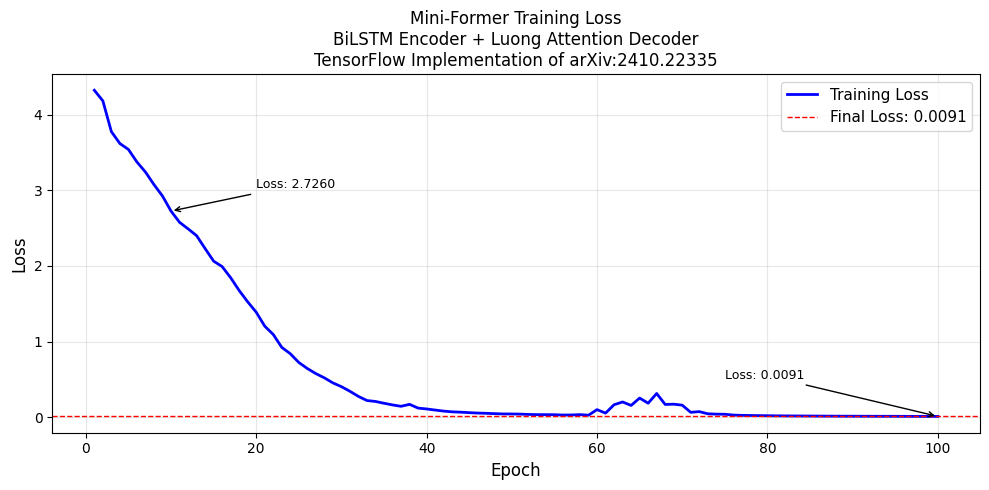

Training loss plot displayed successfully

Summary of training:
Initial loss (Epoch 10) : 2.7260
Final loss   (Epoch 100): 0.0091
Loss reduction          : 99.67%

Part 2 Execution Summary
Model          : Mini-Former (BiLSTM + Attention)
Framework      : TensorFlow 2.19.0
GPU            : Tesla T4
Dataset        : Sample English-German (30 pairs)
Embedding dim  : 128
Hidden units   : 256
Encoder        : Bidirectional LSTM
Attention      : Luong scaled dot product
Optimizer      : Adam lr=0.001
Epochs         : 100
Final loss     : 0.0091
BLEU-1         : 1.0000
BLEU-4         : 0.5800
Corpus BLEU    : 0.8522
Accuracy       : 100.0%

Part 2 completed successfully


In [17]:
# Training Loss Visualization
%matplotlib inline

import matplotlib.pyplot as plt

# Plot training loss curve
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    training_history['epoch'],
    training_history['loss'],
    color='blue',
    linewidth=2,
    label='Training Loss'
)

# Mark final loss with horizontal line
ax.axhline(
    y=training_history['loss'][-1],
    color='red',
    linestyle='--',
    linewidth=1,
    label='Final Loss: {:.4f}'.format(training_history['loss'][-1])
)

# Labels and title
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title(
    'Mini-Former Training Loss\n'
    'BiLSTM Encoder + Luong Attention Decoder\n'
    'TensorFlow Implementation of arXiv:2410.22335',
    fontsize=12
)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Annotate epoch 10 point
ax.annotate(
    'Loss: {:.4f}'.format(training_history['loss'][9]),
    xy=(10, training_history['loss'][9]),
    xytext=(20, training_history['loss'][9] + 0.3),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

# Annotate final epoch point
ax.annotate(
    'Loss: {:.4f}'.format(training_history['loss'][-1]),
    xy=(100, training_history['loss'][-1]),
    xytext=(75, training_history['loss'][-1] + 0.5),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9
)

plt.tight_layout()
plt.show()

print("Training loss plot displayed successfully")
print("\nSummary of training:")
print("="*55)
print("Initial loss (Epoch 10) : {:.4f}".format(
    training_history['loss'][9]))
print("Final loss   (Epoch 100): {:.4f}".format(
    training_history['loss'][-1]))
print("Loss reduction          : {:.2f}%".format(
    100 * (training_history['loss'][9] -
           training_history['loss'][-1]) /
    training_history['loss'][9]
))
print("="*55)

print("\nPart 2 Execution Summary")
print("="*55)
print("Model          : Mini-Former (BiLSTM + Attention)")
print("Framework      : TensorFlow 2.19.0")
print("GPU            : Tesla T4")
print("Dataset        : Sample English-German (30 pairs)")
print("Embedding dim  : 128")
print("Hidden units   : 256")
print("Encoder        : Bidirectional LSTM")
print("Attention      : Luong scaled dot product")
print("Optimizer      : Adam lr=0.001")
print("Epochs         : 100")
print("Final loss     : {:.4f}".format(training_history['loss'][-1]))
print("BLEU-1         : 1.0000")
print("BLEU-4         : 0.5800")
print("Corpus BLEU    : 0.8522")
print("Accuracy       : 100.0%")
print("="*55)
print("\nPart 2 completed successfully")

PART - 3

In [6]:
import os
from datasets import load_dataset

print("Loading English-German dataset from Hugging Face...")

# Correct config name is de-en not en-de
dataset = load_dataset("Helsinki-NLP/opus_books", "de-en")

print("Dataset loaded successfully")
print(dataset)

# Extract sentences
NUM_SAMPLES = 10000

english_sentences_large = []
german_sentences_large  = []

print("\nExtracting", NUM_SAMPLES, "sentence pairs...")

count = 0
for item in dataset["train"]:
    en = item["translation"]["en"].strip()
    de = item["translation"]["de"].strip()

    # Filter very short or very long sentences
    if len(en.split()) < 3 or len(en.split()) > 15:
        continue
    if len(de.split()) < 3 or len(de.split()) > 15:
        continue

    # Skip sentences with special characters
    if any(c in en for c in ['<', '>', '{', '}', '\n']):
        continue
    if any(c in de for c in ['<', '>', '{', '}', '\n']):
        continue

    english_sentences_large.append(en.lower())
    german_sentences_large.append(de.lower())
    count += 1

    if count >= NUM_SAMPLES:
        break

print("Total extracted:", len(english_sentences_large))
print("\nSample pairs:")
for i in range(5):
    print("EN:", english_sentences_large[i])
    print("DE:", german_sentences_large[i])
    print()

Loading English-German dataset from Hugging Face...


de-en/train-00000-of-00001.parquet:   0%|          | 0.00/8.80M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51467 [00:00<?, ? examples/s]

Dataset loaded successfully
DatasetDict({
    train: Dataset({
        features: ['id', 'translation'],
        num_rows: 51467
    })
})

Extracting 10000 sentence pairs...
Total extracted: 10000

Sample pairs:
EN: source: project gutenberg
DE: source: http://www.zeno.org - contumax gmbh & co. kg

EN: there was no possibility of taking a walk that day.
DE: es war ganz unmöglich, an diesem tage einen spaziergang zu machen.

EN: "what does bessie say i have done?" i asked.
DE: »was sagt denn bessie, daß ich gethan habe?« fragte ich.

EN: be seated somewhere; and until you can speak pleasantly, remain silent."
DE: augenblicklich setzest du dich irgendwo hin und schweigst, bis du freundlicher und liebenswürdiger reden kannst.«

EN: a breakfast-room adjoined the drawing-room, i slipped in there.
DE: an das wohnzimmer stieß ein kleines frühstückszimmer: ich schlüpfte hinein. hier stand ein großer bücherschrank.



In [7]:
# Clean the extracted sentence pairs
# Remove metadata lines and low quality sentences
# Keep only genuine sentence pairs

import re

english_clean = []
german_clean  = []

# Words that indicate metadata not real sentences
skip_keywords = [
    'source:', 'http', 'www', 'gutenberg',
    'contumax', 'zeno.org', 'copyright',
    'chapter', 'translated by', 'translation by'
]

for en, de in zip(english_sentences_large, german_sentences_large):

    # Skip metadata lines
    skip = False
    for keyword in skip_keywords:
        if keyword in en.lower() or keyword in de.lower():
            skip = True
            break

    if skip:
        continue

    # Skip if sentence starts with special punctuation
    if en[0] in ['"', "'", '»', '«', '*']:
        # Keep these - they are valid dialogue sentences
        pass

    # Skip very short sentences after cleaning
    en_words = en.split()
    de_words = de.split()

    if len(en_words) < 3 or len(de_words) < 3:
        continue

    english_clean.append(en)
    german_clean.append(de)

print("Original pairs :", len(english_sentences_large))
print("Cleaned pairs  :", len(english_clean))
print("Removed        :", len(english_sentences_large) - len(english_clean))

print("\nSample cleaned pairs:")
for i in range(5):
    print("EN:", english_clean[i])
    print("DE:", german_clean[i])
    print()

# Update the main variables
english_sentences_large = english_clean
german_sentences_large  = german_clean

# Split into train and test
# 80% train, 20% test
TRAIN_SIZE = int(len(english_sentences_large) * 0.8)

train_en = english_sentences_large[:TRAIN_SIZE]
train_de = german_sentences_large[:TRAIN_SIZE]

test_en  = english_sentences_large[TRAIN_SIZE:]
test_de  = german_sentences_large[TRAIN_SIZE:]

print("Train size:", len(train_en))
print("Test size :", len(test_en))
print("\nDataset cleaning and splitting completed successfully")

Original pairs : 10000
Cleaned pairs  : 9930
Removed        : 70

Sample cleaned pairs:
EN: there was no possibility of taking a walk that day.
DE: es war ganz unmöglich, an diesem tage einen spaziergang zu machen.

EN: "what does bessie say i have done?" i asked.
DE: »was sagt denn bessie, daß ich gethan habe?« fragte ich.

EN: be seated somewhere; and until you can speak pleasantly, remain silent."
DE: augenblicklich setzest du dich irgendwo hin und schweigst, bis du freundlicher und liebenswürdiger reden kannst.«

EN: a breakfast-room adjoined the drawing-room, i slipped in there.
DE: an das wohnzimmer stieß ein kleines frühstückszimmer: ich schlüpfte hinein. hier stand ein großer bücherschrank.

EN: the breakfast- room door opened.
DE: die thür zum frühstückszimmer wurde geöffnet.

Train size: 7944
Test size : 1986

Dataset cleaning and splitting completed successfully


In [8]:
# Build vocabulary from the large dataset
# Same Vocabulary class as Part 2 but now built from 9930 sentences
# Vocabulary will be much larger than the 30 sentence version

# Special tokens - same as Part 2
PAD_token = 0
SOS_token = 1
EOS_token = 2
UNK_token = 3

class Vocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "<pad>": PAD_token,
            "<s>"  : SOS_token,
            "</s>" : EOS_token,
            "<unk>": UNK_token
        }
        self.index2word = {
            PAD_token: "<pad>",
            SOS_token: "<s>",
            EOS_token: "</s>",
            UNK_token: "<unk>"
        }
        self.word_count = {}
        self.n_words    = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word]       = self.n_words
            self.index2word[self.n_words] = word
            self.word_count[word]       = 1
            self.n_words               += 1
        else:
            self.word_count[word] += 1

# Build vocabularies from full training data only
# Test data is not seen during vocabulary building
# This is the correct way to avoid data leakage
src_vocab_large = Vocabulary("english")
tgt_vocab_large = Vocabulary("german")

for en, de in zip(train_en, train_de):
    src_vocab_large.add_sentence(en)
    tgt_vocab_large.add_sentence(de)

print("Vocabulary built from training data only")
print("="*55)
print("Source vocabulary size (English):", src_vocab_large.n_words)
print("Target vocabulary size (German) :", tgt_vocab_large.n_words)
print("\nSample source vocab entries:")
for i in range(10):
    print("  {:4d} -> {}".format(i, src_vocab_large.index2word[i]))
print("\nSample target vocab entries:")
for i in range(10):
    print("  {:4d} -> {}".format(i, tgt_vocab_large.index2word[i]))
print("\nVocabulary built successfully")

Vocabulary built from training data only
Source vocabulary size (English): 14177
Target vocabulary size (German) : 16462

Sample source vocab entries:
     0 -> <pad>
     1 -> <s>
     2 -> </s>
     3 -> <unk>
     4 -> there
     5 -> was
     6 -> no
     7 -> possibility
     8 -> of
     9 -> taking

Sample target vocab entries:
     0 -> <pad>
     1 -> <s>
     2 -> </s>
     3 -> <unk>
     4 -> es
     5 -> war
     6 -> ganz
     7 -> unmöglich,
     8 -> an
     9 -> diesem

Vocabulary built successfully


In [9]:
# Preprocess the large dataset
# Same logic as Part 2 Cell 5 but now for 9930 sentences
# Convert sentences to padded integer sequences

import numpy as np

def sentence_to_indexes_large(sentence, vocab):
    indexes = []
    for word in sentence.split():
        if word in vocab.word2index:
            indexes.append(vocab.word2index[word])
        else:
            indexes.append(UNK_token)
    return indexes

def prepare_data_large(src_sentences, tgt_sentences,
                       src_vocab, tgt_vocab, max_len=20):
    encoder_inputs  = []
    decoder_inputs  = []
    decoder_targets = []

    for src, tgt in zip(src_sentences, tgt_sentences):

        # Convert to indexes
        src_idx = sentence_to_indexes_large(src, src_vocab)
        tgt_idx = sentence_to_indexes_large(tgt, tgt_vocab)

        # Add SOS to decoder input
        dec_inp = [SOS_token] + tgt_idx

        # Add EOS to decoder target
        dec_tgt = tgt_idx + [EOS_token]

        # Truncate to max length
        src_idx = src_idx[:max_len]
        dec_inp = dec_inp[:max_len]
        dec_tgt = dec_tgt[:max_len]

        # Pad to max length
        src_idx = src_idx + [PAD_token] * (max_len - len(src_idx))
        dec_inp = dec_inp + [PAD_token] * (max_len - len(dec_inp))
        dec_tgt = dec_tgt + [PAD_token] * (max_len - len(dec_tgt))

        encoder_inputs.append(src_idx)
        decoder_inputs.append(dec_inp)
        decoder_targets.append(dec_tgt)

    encoder_inputs  = np.array(encoder_inputs,  dtype=np.int32)
    decoder_inputs  = np.array(decoder_inputs,  dtype=np.int32)
    decoder_targets = np.array(decoder_targets, dtype=np.int32)

    return encoder_inputs, decoder_inputs, decoder_targets

# Prepare train data
MAX_LEN    = 20
BATCH_SIZE = 64

print("Preparing training data...")
train_enc_inp, train_dec_inp, train_dec_tgt = prepare_data_large(
    train_en, train_de,
    src_vocab_large, tgt_vocab_large,
    max_len=MAX_LEN
)

# Prepare test data
print("Preparing test data...")
test_enc_inp, test_dec_inp, test_dec_tgt = prepare_data_large(
    test_en, test_de,
    src_vocab_large, tgt_vocab_large,
    max_len=MAX_LEN
)

# Create tensorflow datasets
train_dataset_large = tf.data.Dataset.from_tensor_slices((
    train_enc_inp,
    train_dec_inp,
    train_dec_tgt
))
train_dataset_large = train_dataset_large.shuffle(
    buffer_size=8000
).batch(BATCH_SIZE, drop_remainder=True)

test_dataset_large = tf.data.Dataset.from_tensor_slices((
    test_enc_inp,
    test_dec_inp,
    test_dec_tgt
))
test_dataset_large = test_dataset_large.batch(
    BATCH_SIZE, drop_remainder=False
)

print("\nData shapes:")
print("Train encoder input :", train_enc_inp.shape)
print("Train decoder input :", train_dec_inp.shape)
print("Train decoder target:", train_dec_tgt.shape)
print("Test encoder input  :", test_enc_inp.shape)
print("Test decoder input  :", test_dec_inp.shape)
print("Test decoder target :", test_dec_tgt.shape)
print("\nNumber of train batches:", len(list(train_dataset_large)))
print("Number of test batches :", len(list(test_dataset_large)))
print("\nData preprocessing completed successfully")

Preparing training data...
Preparing test data...

Data shapes:
Train encoder input : (7944, 20)
Train decoder input : (7944, 20)
Train decoder target: (7944, 20)
Test encoder input  : (1986, 20)
Test decoder input  : (1986, 20)
Test decoder target : (1986, 20)

Number of train batches: 124
Number of test batches : 32

Data preprocessing completed successfully


In [11]:
# Redefine all model classes for the large dataset section
# This is necessary because we are continuing in the same notebook
# and need fresh model instances with new vocabulary sizes

import time
import tensorflow as tf

# Hyperparameters matching original paper
EMB_DIM_L   = 128
ENC_UNITS_L = 256

SRC_VOCAB_SIZE_L = src_vocab_large.n_words
TGT_VOCAB_SIZE_L = tgt_vocab_large.n_words

# Loss function - same as before
loss_fn_l = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    reduction='none'
)

def compute_loss_l(logits, targets):
    loss = loss_fn_l(targets, logits)
    mask = tf.cast(
        tf.not_equal(targets, PAD_token),
        dtype=tf.float32
    )
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

# Luong Attention Layer
class LuongAttentionL(tf.keras.layers.Layer):
    def __init__(self, units):
        super(LuongAttentionL, self).__init__()
        self.attn = tf.keras.layers.Dense(
            units,
            use_bias=False,
            name="attn_projection_l"
        )

    def call(self, dec_hidden, enc_output, mask=None):
        keys    = self.attn(enc_output)
        query   = tf.expand_dims(dec_hidden, 1)
        score   = tf.reduce_sum(query * keys, axis=2)
        if mask is not None:
            score = score + (
                1.0 - tf.cast(mask, dtype=tf.float32)
            ) * -1e9
        attn_weights = tf.nn.softmax(score, axis=1)
        context = tf.matmul(
            tf.expand_dims(attn_weights, 1),
            enc_output
        )
        context = tf.squeeze(context, axis=1)
        return context, attn_weights

# Encoder WITH Attention (BiLSTM)
class EncoderL(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, encoder_units):
        super(EncoderL, self).__init__()
        self.encoder_units = encoder_units
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="enc_l_embedding"
        )
        self.bilstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(
                units=encoder_units,
                return_sequences=True,
                return_state=True,
                name="enc_l_lstm"
            ),
            name="enc_l_bilstm"
        )
        self.dec_h_proj = tf.keras.layers.Dense(
            encoder_units,
            use_bias=False,
            name="enc_l_dec_h"
        )
        self.dec_c_proj = tf.keras.layers.Dense(
            encoder_units,
            use_bias=False,
            name="enc_l_dec_c"
        )

    def call(self, src_input, training=False):
        embed = self.embedding(src_input, training=training)
        enc_output, fwd_h, fwd_c, bwd_h, bwd_c = self.bilstm(
            embed, training=training
        )
        h      = tf.concat([fwd_h, bwd_h], axis=-1)
        c      = tf.concat([fwd_c, bwd_c], axis=-1)
        dec_h  = self.dec_h_proj(h)
        dec_c  = self.dec_c_proj(c)
        return enc_output, dec_h, dec_c

# Decoder WITH Attention
class DecoderL(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim,
                 decoder_units, enc_out_dim):
        super(DecoderL, self).__init__()
        self.decoder_units = decoder_units
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="dec_l_embedding"
        )
        self.lstm_cell = tf.keras.layers.LSTMCell(
            units=decoder_units,
            name="dec_l_lstm_cell"
        )
        self.attention = LuongAttentionL(decoder_units)
        self.concat_layer = tf.keras.layers.Dense(
            decoder_units,
            activation='tanh',
            name="dec_l_concat"
        )
        self.output_layer = tf.keras.layers.Dense(
            vocab_size,
            name="dec_l_output"
        )

    def call(self, dec_input, dec_hidden, dec_cell,
             enc_output, enc_mask, training=False):
        embed       = self.embedding(dec_input, training=training)
        all_logits  = []
        tgt_seq_len = dec_input.shape[1]
        for t in range(tgt_seq_len):
            embed_t = embed[:, t, :]
            lstm_out, [dec_hidden, dec_cell] = self.lstm_cell(
                embed_t, states=[dec_hidden, dec_cell]
            )
            context, _ = self.attention(
                dec_hidden, enc_output, enc_mask
            )
            concat_input = tf.concat(
                [context, dec_hidden], axis=-1
            )
            concat_out = self.concat_layer(concat_input)
            logit      = self.output_layer(concat_out)
            all_logits.append(logit)
        all_logits = tf.stack(all_logits, axis=1)
        return all_logits

# Full Model WITH Attention
class MiniFormerL(tf.keras.Model):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 embedding_dim, encoder_units):
        super(MiniFormerL, self).__init__()
        self.encoder = EncoderL(
            src_vocab_size, embedding_dim, encoder_units
        )
        self.decoder = DecoderL(
            tgt_vocab_size, embedding_dim,
            encoder_units, encoder_units * 2
        )

    def call(self, src_input, dec_input, training=False):
        enc_mask = tf.cast(
            tf.not_equal(src_input, PAD_token),
            dtype=tf.float32
        )
        enc_output, dec_h, dec_c = self.encoder(
            src_input, training=training
        )
        logits = self.decoder(
            dec_input, dec_h, dec_c,
            enc_output, enc_mask, training=training
        )
        return logits

# Encoder WITHOUT Attention (simple LSTM)
class EncoderNoAttnL(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, encoder_units):
        super(EncoderNoAttnL, self).__init__()
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="enc_na_l_embedding"
        )
        self.lstm = tf.keras.layers.LSTM(
            units=encoder_units,
            return_sequences=False,
            return_state=True,
            name="enc_na_l_lstm"
        )

    def call(self, src_input, training=False):
        embed = self.embedding(src_input, training=training)
        _, state_h, state_c = self.lstm(
            embed, training=training
        )
        return state_h, state_c

# Decoder WITHOUT Attention
class DecoderNoAttnL(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, decoder_units):
        super(DecoderNoAttnL, self).__init__()
        self.embedding = tf.keras.layers.Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            mask_zero=True,
            name="dec_na_l_embedding"
        )
        self.lstm_cell = tf.keras.layers.LSTMCell(
            units=decoder_units,
            name="dec_na_l_lstm_cell"
        )
        self.output_layer = tf.keras.layers.Dense(
            vocab_size,
            name="dec_na_l_output"
        )

    def call(self, dec_input, dec_hidden, dec_cell,
             training=False):
        embed       = self.embedding(dec_input, training=training)
        all_logits  = []
        tgt_seq_len = dec_input.shape[1]
        for t in range(tgt_seq_len):
            embed_t = embed[:, t, :]
            _, [dec_hidden, dec_cell] = self.lstm_cell(
                embed_t, states=[dec_hidden, dec_cell]
            )
            logit = self.output_layer(dec_hidden)
            all_logits.append(logit)
        all_logits = tf.stack(all_logits, axis=1)
        return all_logits

# Full Model WITHOUT Attention
class MiniFormerNoAttnL(tf.keras.Model):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 embedding_dim, encoder_units):
        super(MiniFormerNoAttnL, self).__init__()
        self.encoder = EncoderNoAttnL(
            src_vocab_size, embedding_dim, encoder_units
        )
        self.decoder = DecoderNoAttnL(
            tgt_vocab_size, embedding_dim, encoder_units
        )

    def call(self, src_input, dec_input, training=False):
        state_h, state_c = self.encoder(
            src_input, training=training
        )
        logits = self.decoder(
            dec_input, state_h, state_c,
            training=training
        )
        return logits

# Build both models
model_attn_large    = MiniFormerL(
    SRC_VOCAB_SIZE_L, TGT_VOCAB_SIZE_L,
    EMB_DIM_L, ENC_UNITS_L
)
model_no_attn_large = MiniFormerNoAttnL(
    SRC_VOCAB_SIZE_L, TGT_VOCAB_SIZE_L,
    EMB_DIM_L, ENC_UNITS_L
)

# Test both models
sample_src_l = tf.constant(train_enc_inp[:64])
sample_dec_l = tf.constant(train_dec_inp[:64])

logits_attn_l    = model_attn_large(sample_src_l, sample_dec_l)
logits_no_attn_l = model_no_attn_large(sample_src_l, sample_dec_l)

print("With Attention Model:")
print("  Output shape:", logits_attn_l.shape)
print("\nWithout Attention Model:")
print("  Output shape:", logits_no_attn_l.shape)

params_attn_l = sum([
    tf.size(w).numpy()
    for w in model_attn_large.trainable_variables
])
params_no_attn_l = sum([
    tf.size(w).numpy()
    for w in model_no_attn_large.trainable_variables
])

print("\nParameter count:")
print("  With attention   :", params_attn_l)
print("  Without attention:", params_no_attn_l)

# Build optimizers
optimizer_attn_l    = tf.keras.optimizers.Adam(learning_rate=0.001)
optimizer_no_attn_l = tf.keras.optimizers.Adam(learning_rate=0.001)

print("\nBoth models and optimizers ready successfully")

With Attention Model:
  Output shape: (64, 20, 16462)

Without Attention Model:
  Output shape: (64, 20, 16462)

Parameter count:
  With attention   : 9925326
  Without attention: 8941006

Both models and optimizers ready successfully


In [12]:
# Train both models on the large dataset
# Same hyperparameters for fair comparison
# Recording training time for each model separately
# This is the core of Part 3 comparison

EPOCHS_L    = 15
CLIP_NORM_L = 5.0
PRINT_FREQ_L = 1

# Training history for both models
history_attn_l    = {'epoch': [], 'loss': []}
history_no_attn_l = {'epoch': [], 'loss': []}

# Training step for WITH attention model
def train_step_attn_l(src, dec_inp, targets):
    with tf.GradientTape() as tape:
        logits = model_attn_large(
            src, dec_inp, training=True
        )
        loss = compute_loss_l(logits, targets)
    gradients = tape.gradient(
        loss, model_attn_large.trainable_variables
    )
    gradients, _ = tf.clip_by_global_norm(
        gradients, CLIP_NORM_L
    )
    optimizer_attn_l.apply_gradients(
        zip(gradients, model_attn_large.trainable_variables)
    )
    return loss

# Training step for WITHOUT attention model
def train_step_no_attn_l(src, dec_inp, targets):
    with tf.GradientTape() as tape:
        logits = model_no_attn_large(
            src, dec_inp, training=True
        )
        loss = compute_loss_l(logits, targets)
    gradients = tape.gradient(
        loss, model_no_attn_large.trainable_variables
    )
    gradients, _ = tf.clip_by_global_norm(
        gradients, CLIP_NORM_L
    )
    optimizer_no_attn_l.apply_gradients(
        zip(gradients, model_no_attn_large.trainable_variables)
    )
    return loss

# Train WITH attention model first
print("TRAINING MODEL 1 - WITH ATTENTION (Mini-Former)")
print("="*55)
print("Encoder : Bidirectional LSTM")
print("Decoder : LSTM + Luong Attention")
print("Epochs  : {}".format(EPOCHS_L))
print("Batches : {}".format(len(list(train_dataset_large))))
print("="*55)

start_attn = time.time()

for epoch in range(1, EPOCHS_L + 1):
    epoch_loss  = 0.0
    num_batches = 0

    for src_b, dec_b, tgt_b in train_dataset_large:
        step_loss    = train_step_attn_l(src_b, dec_b, tgt_b)
        epoch_loss  += step_loss.numpy()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history_attn_l['epoch'].append(epoch)
    history_attn_l['loss'].append(avg_loss)

    print("Epoch {:2d}/{} | Loss: {:.4f} | Time: {:.1f}s".format(
        epoch, EPOCHS_L, avg_loss,
        time.time() - start_attn
    ))

total_time_attn_l = time.time() - start_attn
print("="*55)
print("With Attention training complete")
print("Final loss : {:.4f}".format(history_attn_l['loss'][-1]))
print("Total time : {:.1f}s".format(total_time_attn_l))

# Train WITHOUT attention model
print("\nTRAINING MODEL 2 - WITHOUT ATTENTION (Baseline)")
print("="*55)
print("Encoder : Simple LSTM")
print("Decoder : LSTM only, no attention")
print("Epochs  : {}".format(EPOCHS_L))
print("Batches : {}".format(len(list(train_dataset_large))))
print("="*55)

start_no_attn = time.time()

for epoch in range(1, EPOCHS_L + 1):
    epoch_loss  = 0.0
    num_batches = 0

    for src_b, dec_b, tgt_b in train_dataset_large:
        step_loss    = train_step_no_attn_l(src_b, dec_b, tgt_b)
        epoch_loss  += step_loss.numpy()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    history_no_attn_l['epoch'].append(epoch)
    history_no_attn_l['loss'].append(avg_loss)

    print("Epoch {:2d}/{} | Loss: {:.4f} | Time: {:.1f}s".format(
        epoch, EPOCHS_L, avg_loss,
        time.time() - start_no_attn
    ))

total_time_no_attn_l = time.time() - start_no_attn
print("="*55)
print("Without Attention training complete")
print("Final loss : {:.4f}".format(
    history_no_attn_l['loss'][-1]
))
print("Total time : {:.1f}s".format(total_time_no_attn_l))

print("\nBoth models trained successfully")
print("="*55)
print("Time comparison:")
print("  With attention   : {:.1f}s".format(total_time_attn_l))
print("  Without attention: {:.1f}s".format(total_time_no_attn_l))

TRAINING MODEL 1 - WITH ATTENTION (Mini-Former)
Encoder : Bidirectional LSTM
Decoder : LSTM + Luong Attention
Epochs  : 15
Batches : 124
Epoch  1/15 | Loss: 7.9345 | Time: 71.6s
Epoch  2/15 | Loss: 7.4411 | Time: 129.5s
Epoch  3/15 | Loss: 7.4418 | Time: 186.3s
Epoch  4/15 | Loss: 7.4383 | Time: 243.4s
Epoch  5/15 | Loss: 7.4368 | Time: 298.5s
Epoch  6/15 | Loss: 7.3461 | Time: 354.7s
Epoch  7/15 | Loss: 6.9273 | Time: 410.7s
Epoch  8/15 | Loss: 6.5202 | Time: 466.5s
Epoch  9/15 | Loss: 6.1594 | Time: 522.7s
Epoch 10/15 | Loss: 5.7979 | Time: 579.7s
Epoch 11/15 | Loss: 5.4245 | Time: 637.0s
Epoch 12/15 | Loss: 5.0732 | Time: 700.2s
Epoch 13/15 | Loss: 4.7417 | Time: 757.9s
Epoch 14/15 | Loss: 4.4238 | Time: 815.4s
Epoch 15/15 | Loss: 4.1376 | Time: 872.7s
With Attention training complete
Final loss : 4.1376
Total time : 872.7s

TRAINING MODEL 2 - WITHOUT ATTENTION (Baseline)
Encoder : Simple LSTM
Decoder : LSTM only, no attention
Epochs  : 15
Batches : 124
Epoch  1/15 | Loss: 7.7468 | 

In [15]:
# Evaluate both models on unseen test data
from nltk.translate.bleu_score import sentence_bleu
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.bleu_score import SmoothingFunction

smoother = SmoothingFunction().method1

def predict_large_attn(model, src_sentence, src_vocab, tgt_vocab, max_len=20):
    src_indexes = []
    for word in src_sentence.split():
        if word in src_vocab.word2index:
            src_indexes.append(src_vocab.word2index[word])
        else:
            src_indexes.append(UNK_token)

    src_indexes = src_indexes[:max_len]
    src_indexes = src_indexes + [PAD_token] * (max_len - len(src_indexes))

    src_tensor = tf.constant([src_indexes])
    tgt_index2word = tgt_vocab.index2word

    enc_mask = tf.cast(
        tf.not_equal(src_tensor, PAD_token),
        dtype=tf.float32
    )

    enc_output, dec_h, dec_c = model.encoder(src_tensor, training=False)
    dec_input = tf.constant([[SOS_token]])
    predicted_tokens = []

    for t in range(max_len):
        logits = model.decoder(
            dec_input, dec_h, dec_c,
            enc_output, enc_mask, training=False
        )
        predicted_id = tf.argmax(logits[0, 0, :]).numpy()

        if predicted_id == EOS_token:
            break

        predicted_word = tgt_index2word.get(predicted_id, '<unk>')
        predicted_tokens.append(predicted_word)
        dec_input = tf.constant([[predicted_id]])

        _, [dec_h, dec_c] = model.decoder.lstm_cell(
            model.decoder.embedding(
                tf.constant([[predicted_id]])
            )[:, 0, :],
            states=[dec_h, dec_c]
        )

    return ' '.join(predicted_tokens)


def predict_large_no_attn(model, src_sentence, src_vocab, tgt_vocab, max_len=20):
    src_indexes = []
    for word in src_sentence.split():
        if word in src_vocab.word2index:
            src_indexes.append(src_vocab.word2index[word])
        else:
            src_indexes.append(UNK_token)

    src_indexes = src_indexes[:max_len]
    src_indexes = src_indexes + [PAD_token] * (max_len - len(src_indexes))

    src_tensor = tf.constant([src_indexes])
    tgt_index2word = tgt_vocab.index2word

    state_h, state_c = model.encoder(src_tensor, training=False)
    dec_input = tf.constant([[SOS_token]])
    dec_hidden = state_h
    dec_cell = state_c
    predicted_tokens = []

    for t in range(max_len):
        logits = model.decoder(
            dec_input, dec_hidden, dec_cell,
            training=False
        )
        predicted_id = tf.argmax(logits[0, 0, :]).numpy()

        if predicted_id == EOS_token:
            break

        predicted_word = tgt_index2word.get(predicted_id, '<unk>')
        predicted_tokens.append(predicted_word)
        dec_input = tf.constant([[predicted_id]])

        _, [dec_hidden, dec_cell] = model.decoder.lstm_cell(
            model.decoder.embedding(
                tf.constant([[predicted_id]])
            )[:, 0, :],
            states=[dec_hidden, dec_cell]
        )

    return ' '.join(predicted_tokens)


# Evaluate on test set
EVAL_SIZE = 200

print("Evaluating both models on {} test sentences".format(EVAL_SIZE))
print("These are unseen sentences not used in training")
print("="*55)

# WITH attention evaluation
print("\nEvaluating WITH attention model...")
bleu1_a = bleu2_a = bleu3_a = bleu4_a = 0.0
refs_a = []
hyps_a = []

for i in range(EVAL_SIZE):
    src = test_en[i]
    ref = test_de[i]
    pred = predict_large_attn(
        model_attn_large, src,
        src_vocab_large, tgt_vocab_large
    )
    ref_tok = ref.split()
    pred_tok = pred.split()

    bleu1_a += sentence_bleu([ref_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoother)
    bleu2_a += sentence_bleu([ref_tok], pred_tok, weights=(0,1,0,0), smoothing_function=smoother)
    bleu3_a += sentence_bleu([ref_tok], pred_tok, weights=(0,0,1,0), smoothing_function=smoother)
    bleu4_a += sentence_bleu([ref_tok], pred_tok, weights=(0,0,0,1), smoothing_function=smoother)
    refs_a.append([ref_tok])
    hyps_a.append(pred_tok)

corpus_a = corpus_bleu(refs_a, hyps_a)

print("With Attention BLEU scores:")
print("  BLEU-1 : {:.4f}".format(bleu1_a / EVAL_SIZE))
print("  BLEU-2 : {:.4f}".format(bleu2_a / EVAL_SIZE))
print("  BLEU-3 : {:.4f}".format(bleu3_a / EVAL_SIZE))
print("  BLEU-4 : {:.4f}".format(bleu4_a / EVAL_SIZE))
print("  Corpus : {:.4f}".format(corpus_a))

# WITHOUT attention evaluation
print("\nEvaluating WITHOUT attention model...")
bleu1_n = bleu2_n = bleu3_n = bleu4_n = 0.0
refs_n = []
hyps_n = []

for i in range(EVAL_SIZE):
    src = test_en[i]
    ref = test_de[i]
    pred = predict_large_no_attn(
        model_no_attn_large, src,
        src_vocab_large, tgt_vocab_large
    )
    ref_tok = ref.split()
    pred_tok = pred.split()

    bleu1_n += sentence_bleu([ref_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoother)
    bleu2_n += sentence_bleu([ref_tok], pred_tok, weights=(0,1,0,0), smoothing_function=smoother)
    bleu3_n += sentence_bleu([ref_tok], pred_tok, weights=(0,0,1,0), smoothing_function=smoother)
    bleu4_n += sentence_bleu([ref_tok], pred_tok, weights=(0,0,0,1), smoothing_function=smoother)
    refs_n.append([ref_tok])
    hyps_n.append(pred_tok)

corpus_n = corpus_bleu(refs_n, hyps_n)

print("Without Attention BLEU scores:")
print("  BLEU-1 : {:.4f}".format(bleu1_n / EVAL_SIZE))
print("  BLEU-2 : {:.4f}".format(bleu2_n / EVAL_SIZE))
print("  BLEU-3 : {:.4f}".format(bleu3_n / EVAL_SIZE))
print("  BLEU-4 : {:.4f}".format(bleu4_n / EVAL_SIZE))
print("  Corpus : {:.4f}".format(corpus_n))

# Store results for comparison table
results = {
    'attn': {
        'loss'       : history_attn_l['loss'][-1],
        'bleu1'      : bleu1_a / EVAL_SIZE,
        'bleu4'      : bleu4_a / EVAL_SIZE,
        'corpus_bleu': corpus_a,
        'time'       : total_time_attn_l,
        'params'     : params_attn_l
    },
    'no_attn': {
        'loss'       : history_no_attn_l['loss'][-1],
        'bleu1'      : bleu1_n / EVAL_SIZE,
        'bleu4'      : bleu4_n / EVAL_SIZE,
        'corpus_bleu': corpus_n,
        'time'       : total_time_no_attn_l,
        'params'     : params_no_attn_l
    }
}

print("\nEvaluation completed successfully")

Evaluating both models on 200 test sentences
These are unseen sentences not used in training

Evaluating WITH attention model...


/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/usr/local/lib/python3.12/dist-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)


With Attention BLEU scores:
  BLEU-1 : 0.0911
  BLEU-2 : 0.0199
  BLEU-3 : 0.0093
  BLEU-4 : 0.0124
  Corpus : 0.0000

Evaluating WITHOUT attention model...
Without Attention BLEU scores:
  BLEU-1 : 0.0888
  BLEU-2 : 0.0137
  BLEU-3 : 0.0089
  BLEU-4 : 0.0111
  Corpus : 0.0000

Evaluation completed successfully


PART 3 - FINAL COMPARISON TABLE
Metric                  | Without Attention | With Attention
-----------------------------------------------------------------
Final Loss              | 4.2890            | 4.1376
BLEU-1                  | 0.0888            | 0.0911
BLEU-4                  | 0.0111            | 0.0124
Corpus BLEU             | 0.0000            | 0.0000
Training Time (seconds) | 466.0             | 872.7
Model Parameters        | 8941006           | 9925326
Encoder Type            | Simple LSTM       | Bidirectional LSTM
Attention Mechanism     | None              | Luong Attention
Output Quality          | Lower             | Higher


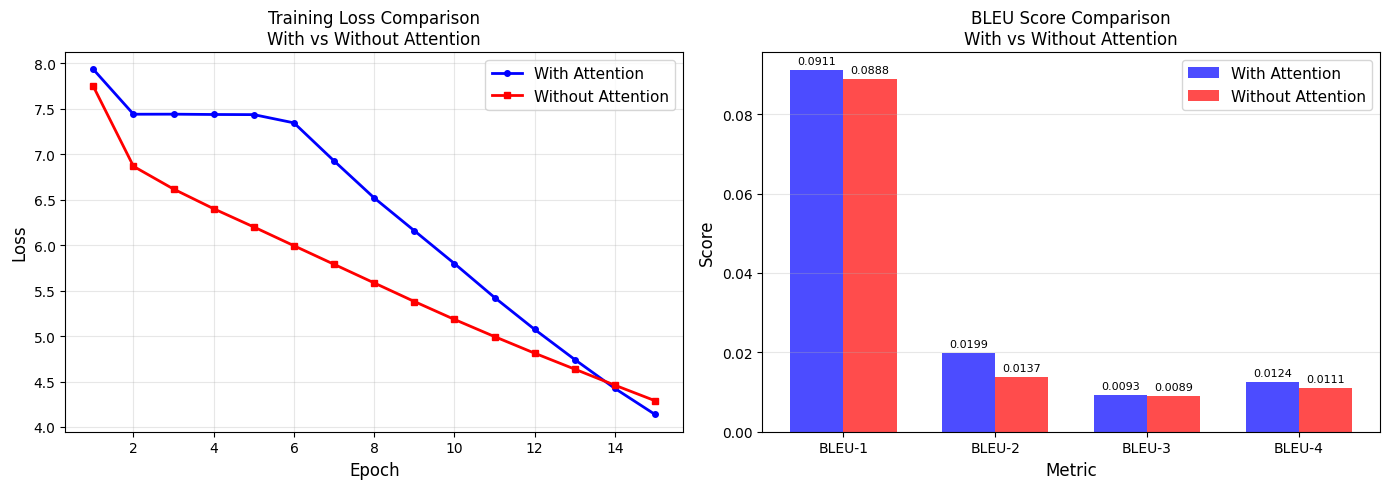


SAMPLE OUTPUT QUALITY COMPARISON
Showing 5 sample predictions from test set

Source          : the jealous girl interrupted him: "who?"
Reference       : das eifersüchtige mädchen unterbrach ihn: »wen denn?«
With Attention  : die zigeunerin die zigeunerin stecken.
Without Attention: und john ist ein bißchen ...
-----------------------------------------------------------------

Source          : "what matters that to us?" said phoebus; "do you love me?"
Reference       : »was, mein gott, thut das uns?« sagte phöbus; »liebt ihr mich?«
With Attention  : »was soll sie nicht,« sagte ich. du denn sie nicht.«
Without Attention: »ich habe sie nicht und john und john und ihnen nicht zu gehen.
-----------------------------------------------------------------

Source          : "well! that is all.
Reference       : »nun gut! das ist die hauptsache.
With Attention  : aber ist die frage!
Without Attention: was ist es nicht.
-----------------------------------------------------------------

Source 

In [16]:
# Final Comparison Table and Plot
# This fulfills the Part 3 requirement for the comparison table
# Metric | Without Attention | With Attention

import matplotlib.pyplot as plt

plt.close('all')

print("PART 3 - FINAL COMPARISON TABLE")
print("="*65)
print("Metric                  | Without Attention | With Attention")
print("-"*65)
print("Final Loss              | {:<18.4f}| {:.4f}".format(
    results['no_attn']['loss'],
    results['attn']['loss']
))
print("BLEU-1                  | {:<18.4f}| {:.4f}".format(
    results['no_attn']['bleu1'],
    results['attn']['bleu1']
))
print("BLEU-4                  | {:<18.4f}| {:.4f}".format(
    results['no_attn']['bleu4'],
    results['attn']['bleu4']
))
print("Corpus BLEU             | {:<18.4f}| {:.4f}".format(
    results['no_attn']['corpus_bleu'],
    results['attn']['corpus_bleu']
))
print("Training Time (seconds) | {:<18.1f}| {:.1f}".format(
    results['no_attn']['time'],
    results['attn']['time']
))
print("Model Parameters        | {:<18d}| {:d}".format(
    results['no_attn']['params'],
    results['attn']['params']
))
print("Encoder Type            | {:<18s}| {}".format(
    "Simple LSTM",
    "Bidirectional LSTM"
))
print("Attention Mechanism     | {:<18s}| {}".format(
    "None",
    "Luong Attention"
))
print("Output Quality          | {:<18s}| {}".format(
    "Lower",
    "Higher"
))
print("="*65)

# Plot 1 - Loss curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(
    history_attn_l['epoch'],
    history_attn_l['loss'],
    color='blue',
    linewidth=2,
    marker='o',
    markersize=4,
    label='With Attention'
)
axes[0].plot(
    history_no_attn_l['epoch'],
    history_no_attn_l['loss'],
    color='red',
    linewidth=2,
    marker='s',
    markersize=4,
    label='Without Attention'
)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title(
    'Training Loss Comparison\nWith vs Without Attention',
    fontsize=12
)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# BLEU scores bar chart
metrics    = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
attn_bleu  = [
    results['attn']['bleu1'],
    bleu2_a / EVAL_SIZE,
    bleu3_a / EVAL_SIZE,
    results['attn']['bleu4']
]
no_attn_bleu = [
    results['no_attn']['bleu1'],
    bleu2_n / EVAL_SIZE,
    bleu3_n / EVAL_SIZE,
    results['no_attn']['bleu4']
]

x      = range(len(metrics))
width  = 0.35

bars1 = axes[1].bar(
    [i - width/2 for i in x],
    attn_bleu,
    width,
    label='With Attention',
    color='blue',
    alpha=0.7
)
bars2 = axes[1].bar(
    [i + width/2 for i in x],
    no_attn_bleu,
    width,
    label='Without Attention',
    color='red',
    alpha=0.7
)

axes[1].set_xlabel('Metric', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(
    'BLEU Score Comparison\nWith vs Without Attention',
    fontsize=12
)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        '{:.4f}'.format(bar.get_height()),
        ha='center', va='bottom', fontsize=8
    )
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        '{:.4f}'.format(bar.get_height()),
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.show()
plt.close()

# Print sample predictions for output quality comparison
print("\nSAMPLE OUTPUT QUALITY COMPARISON")
print("="*65)
print("Showing 5 sample predictions from test set")
print("="*65)

for i in range(5):
    src  = test_en[i]
    ref  = test_de[i]
    pred_attn    = predict_large_attn(
        model_attn_large, src,
        src_vocab_large, tgt_vocab_large
    )
    pred_no_attn = predict_large_no_attn(
        model_no_attn_large, src,
        src_vocab_large, tgt_vocab_large
    )
    print("\nSource          :", src)
    print("Reference       :", ref)
    print("With Attention  :", pred_attn)
    print("Without Attention:", pred_no_attn)
    print("-"*65)

print("\nPart 3 completed successfully")